In [1]:
print("Jupyter is working!")

Jupyter is working!


In [1]:
import pandas as pd
import numpy as np

# Make the dataset reproducible
np.random.seed(42)

# Number of customers
n = 1000

# Create customer IDs
customer_id = [f"CUST_{i:04d}" for i in range(1, n + 1)]

# Basic customer information
age = np.random.randint(18, 71, n)

gender = np.random.choice(
    ["Male", "Female"],
    size=n,
    p=[0.52, 0.48]
)

education = np.random.choice(
    ["High School", "Bachelor", "Master", "PhD"],
    size=n,
    p=[0.25, 0.45, 0.25, 0.05]
)

city = np.random.choice(
    ["Bangalore", "Mumbai", "Delhi", "Chennai", "Hyderabad"],
    size=n,
    p=[0.30, 0.20, 0.20, 0.15, 0.15]
)

# Income is related to age and education
education_bonus = np.select(
    [
        education == "High School",
        education == "Bachelor",
        education == "Master",
        education == "PhD"
    ],
    [
        0,
        15000,
        30000,
        50000
    ]
)

income = (
    25000
    + age * 1200
    + education_bonus
    + np.random.normal(0, 10000, n)
)

income = np.maximum(income, 15000).round(2)

# Credit score is related to income and age
credit_score = (
    500
    + income / 1000 * 1.5
    + age * 1.2
    + np.random.normal(0, 35, n)
)

credit_score = np.clip(credit_score, 300, 850).round().astype(int)

# Purchase amount is related to income
purchase_amount = (
    income * np.random.uniform(0.005, 0.025, n)
    + np.random.normal(0, 50, n)
)

purchase_amount = np.maximum(purchase_amount, 10).round(2)

# Churn probability
churn_probability = (
    0.30
    - (credit_score - 600) / 2000
    + np.where(purchase_amount < 200, 0.08, 0)
)

churn_probability = np.clip(churn_probability, 0.05, 0.60)

churn = np.random.binomial(1, churn_probability)

# Create dataframe
df = pd.DataFrame({
    "customer_id": customer_id,
    "age": age,
    "gender": gender,
    "income": income,
    "education": education,
    "city": city,
    "credit_score": credit_score,
    "purchase_amount": purchase_amount,
    "churn": churn
})

# Display first 10 rows
df.head(10)

,customer_id,age,gender,income,education,city,credit_score,purchase_amount,churn
0,CUST_0001,56,Female,108554.02,Bachelor,Hyderabad,705,879.36,0
1,CUST_0002,69,Female,91115.61,High School,Mumbai,714,1729.00,1
2,CUST_0003,46,Male,155495.65,PhD,Mumbai,827,2365.40,0
3,CUST_0004,32,Female,84644.19,Bachelor,Hyderabad,674,1636.36,0
4,CUST_0005,60,Female,133701.00,Master,Delhi,743,1110.51,0
5,CUST_0006,25,Female,68658.18,High School,Bangalore,680,1371.88,1
6,CUST_0007,38,Male,79791.76,Bachelor,Bangalore,615,1941.59,0
7,CUST_0008,56,Male,108504.54,Bachelor,Delhi,738,2037.31,0
8,CUST_0009,36,Male,85006.78,Master,Hyderabad,617,1252.17,1
9,CUST_0010,40,Female,66920.52,High School,Chennai,657,1576.72,1


In [2]:
df.shape


(1000, 9)

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customer_id', 'age', 'gender', 'income', 'education', 'city', 'credit_score', 'purchase_amount', 'churn']

Data types:
customer_id         object
age                  int32
gender              object
income             float64
education           object
city                object
credit_score         int64
purchase_amount    float64
churn                int32
dtype: object

Missing values:
customer_id        0
age                0
gender             0
income             0
education          0
city               0
credit_score       0
purchase_amount    0
churn              0
dtype: int64

Duplicate rows: 0


In [4]:
df.to_csv("../data/raw/customer_data.csv", index=False)

print("Dataset saved successfully!")


Dataset saved successfully!


In [5]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
c:\Users\NISHCHAL\Desktop\synthetic-data-generator\notebooks


In [6]:
import os

file_path = "../data/raw/customer_data.csv"

print("File exists:", os.path.exists(file_path))
print("Full path:", os.path.abspath(file_path))

File exists: True
Full path: c:\Users\NISHCHAL\Desktop\synthetic-data-generator\data\raw\customer_data.csv


In [7]:
print("Gender:")
print(df["gender"].value_counts())

print("\nEducation:")
print(df["education"].value_counts())

print("\nCity:")
print(df["city"].value_counts())

print("\nChurn:")
print(df["churn"].value_counts())


Gender:
gender
Female    513
Male      487
Name: count, dtype: int64

Education:
education
Bachelor       432
High School    267
Master         250
PhD             51
Name: count, dtype: int64

City:
city
Bangalore    259
Delhi        211
Mumbai       207
Chennai      164
Hyderabad    159
Name: count, dtype: int64

Churn:
churn
0    752
1    248
Name: count, dtype: int64


In [8]:
df.describe()

,age,income,credit_score,purchase_amount,churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.385000,94690.937480,694.430000,1420.000030,0.248000
std,15.321669,24371.937431,61.990999,658.240179,0.432068
min,18.000000,27278.860000,532.000000,55.360000,0.000000
25%,31.750000,77760.472500,650.750000,894.042500,0.000000
50%,45.000000,95166.150000,697.000000,1339.915000,0.000000
75%,57.000000,111460.842500,737.000000,1870.355000,0.000000
max,70.000000,170801.770000,850.000000,3797.740000,1.000000


In [9]:
categorical_columns = [
    "gender",
    "education",
    "city"
]

numerical_columns = [
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]

target_column = "churn"

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)
print("Target column:", target_column)

Categorical columns: ['gender', 'education', 'city']
Numerical columns: ['age', 'income', 'credit_score', 'purchase_amount']
Target column: churn


In [10]:
model_data = df.drop(columns=["customer_id"]).copy()

print("Original dataset shape:", df.shape)
print("Model dataset shape:", model_data.shape)
print("\nModel columns:")
print(model_data.columns.tolist())

Original dataset shape: (1000, 9)
Model dataset shape: (1000, 8)

Model columns:
['age', 'gender', 'income', 'education', 'city', 'credit_score', 'purchase_amount', 'churn']


In [11]:
from sklearn.model_selection import train_test_split

train_data, holdout_data = train_test_split(
    model_data,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", train_data.shape)
print("Holdout data shape:", holdout_data.shape)

Training data shape: (800, 8)
Holdout data shape: (200, 8)


In [12]:
holdout_data.to_csv("../data/processed/holdout_data.csv", index=False)

print("Holdout data saved successfully!")

Holdout data saved successfully!


In [13]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(
    data=train_data
)

print(metadata)

{
    "tables": {
        "table": {
            "columns": {
                "age": {
                    "sdtype": "numerical"
                },
                "gender": {
                    "sdtype": "categorical"
                },
                "income": {
                    "sdtype": "numerical"
                },
                "education": {
                    "sdtype": "categorical"
                },
                "city": {
                    "pii": true,
                    "sdtype": "city"
                },
                "credit_score": {
                    "sdtype": "numerical"
                },
                "purchase_amount": {
                    "sdtype": "numerical"
                },
                "churn": {
                    "sdtype": "categorical"
                }
            }
        }
    },
    "relationships": [],
    "METADATA_SPEC_VERSION": "V1"
}


In [14]:
metadata.update_column(
    column_name="city",
    sdtype="categorical"
)

print(metadata)

{
    "tables": {
        "table": {
            "columns": {
                "age": {
                    "sdtype": "numerical"
                },
                "gender": {
                    "sdtype": "categorical"
                },
                "income": {
                    "sdtype": "numerical"
                },
                "education": {
                    "sdtype": "categorical"
                },
                "city": {
                    "sdtype": "categorical"
                },
                "credit_score": {
                    "sdtype": "numerical"
                },
                "purchase_amount": {
                    "sdtype": "numerical"
                },
                "churn": {
                    "sdtype": "categorical"
                }
            }
        }
    },
    "relationships": [],
    "METADATA_SPEC_VERSION": "V1"
}


In [15]:
print("Churn metadata:")
print(metadata.get_table("table").columns["churn"])

Churn metadata:


AttributeError: 'Metadata' object has no attribute 'get_table'

In [16]:
metadata_dict = metadata.to_dict()

print("Churn metadata:")
print(metadata_dict["tables"]["table"]["columns"]["churn"])

Churn metadata:
{'sdtype': 'categorical'}


In [17]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(
    metadata
)

print("Gaussian Copula synthesizer created successfully!")


Gaussian Copula synthesizer created successfully!


c:\Users\NISHCHAL\Desktop\synthetic-data-generator\.venv\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [18]:
synthesizer.fit(train_data)

print("Gaussian Copula model trained successfully!")

Gaussian Copula model trained successfully!


In [19]:
synthetic_data = synthesizer.sample(
    num_rows=800
)

print("Synthetic data generated successfully!")
print("Synthetic data shape:", synthetic_data.shape)

Synthetic data generated successfully!
Synthetic data shape: (800, 8)


In [20]:
synthetic_data.head(10)


,age,gender,income,education,city,credit_score,purchase_amount,churn
0,58,Male,119441.60,Bachelor,Mumbai,739,2092.20,0
1,31,Male,80137.69,Bachelor,Mumbai,629,798.93,0
2,67,Female,106529.03,Bachelor,Chennai,688,1711.74,0
3,70,Female,148036.09,Bachelor,Bangalore,809,1870.73,0
4,49,Female,116643.78,Bachelor,Delhi,776,1382.19,0
5,37,Female,100545.64,Bachelor,Chennai,720,1251.63,0
6,51,Male,80269.98,Master,Mumbai,641,1010.52,0
7,24,Female,57816.42,Bachelor,Bangalore,625,1917.04,0
8,35,Female,55517.83,High School,Mumbai,596,934.23,0
9,40,Male,75058.82,High School,Bangalore,645,551.59,0


In [21]:
print("REAL TRAINING DATA")
print(train_data[[
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]].describe())

print("\nSYNTHETIC DATA")
print(synthetic_data[[
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]].describe())

REAL TRAINING DATA
              age         income  credit_score  purchase_amount
count  800.000000     800.000000    800.000000         800.0000
mean    43.940000   94098.217825    692.356250        1399.4981
std     15.147961   24117.844876     62.005667         646.9982
min     18.000000   30909.000000    532.000000          55.3600
25%     31.750000   77565.530000    648.750000         881.9025
50%     44.000000   94410.835000    694.500000        1335.4300
75%     56.000000  110905.255000    733.250000        1855.2750
max     70.000000  170801.770000    850.000000        3518.2200

SYNTHETIC DATA
              age         income  credit_score  purchase_amount
count  800.000000     800.000000     800.00000       800.000000
mean    43.775000   92482.338825     690.25000      1384.840063
std     15.828299   24472.864194      61.80143       627.529724
min     18.000000   36991.790000     535.00000       146.110000
25%     30.000000   75045.370000     645.00000       940.342500
50%  

In [22]:
from scipy.stats import ks_2samp

numeric_columns = [
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]

for column in numeric_columns:
    statistic, p_value = ks_2samp(
        train_data[column],
        synthetic_data[column]
    )

    print(f"{column}")
    print(f"  KS statistic: {statistic:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print()

age
  KS statistic: 0.0525
  p-value: 0.2203

income
  KS statistic: 0.0625
  p-value: 0.0879

credit_score
  KS statistic: 0.0350
  p-value: 0.7116

purchase_amount
  KS statistic: 0.0413
  p-value: 0.5043



In [23]:
categorical_columns = [
    "gender",
    "education",
    "city",
    "churn"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")

    real_distribution = train_data[column].value_counts(
        normalize=True
    ).sort_index()

    synthetic_distribution = synthetic_data[column].value_counts(
        normalize=True
    ).sort_index()

    comparison = pd.DataFrame({
        "Real": real_distribution,
        "Synthetic": synthetic_distribution
    }).fillna(0)

    print(comparison)


GENDER
          Real  Synthetic
gender                   
Female  0.5125    0.52125
Male    0.4875    0.47875

EDUCATION
                Real  Synthetic
education                      
Bachelor     0.43375    0.42625
High School  0.27500    0.27125
Master       0.24000    0.25250
PhD          0.05125    0.05000

CITY
              Real  Synthetic
city                         
Bangalore  0.27000    0.27000
Chennai    0.16625    0.16250
Delhi      0.21000    0.22500
Hyderabad  0.15125    0.14625
Mumbai     0.20250    0.19625

CHURN
         Real  Synthetic
churn                   
0      0.7525    0.77375
1      0.2475    0.22625


In [24]:
real_correlation = train_data[
    ["age", "income", "credit_score", "purchase_amount"]
].corr()

synthetic_correlation = synthetic_data[
    ["age", "income", "credit_score", "purchase_amount"]
].corr()

print("REAL DATA CORRELATION")
print(real_correlation.round(2))

print("\nSYNTHETIC DATA CORRELATION")
print(synthetic_correlation.round(2))

REAL DATA CORRELATION
                  age  income  credit_score  purchase_amount
age              1.00    0.74          0.75             0.39
income           0.74    1.00          0.81             0.53
credit_score     0.75    0.81          1.00             0.45
purchase_amount  0.39    0.53          0.45             1.00

SYNTHETIC DATA CORRELATION
                  age  income  credit_score  purchase_amount
age              1.00    0.65          0.63             0.33
income           0.65    1.00          0.82             0.52
credit_score     0.63    0.82          1.00             0.46
purchase_amount  0.33    0.52          0.46             1.00


In [25]:
correlation_difference = (
    real_correlation - synthetic_correlation
).abs()

mean_correlation_error = correlation_difference.values[
    ~np.eye(correlation_difference.shape[0], dtype=bool)
].mean()

correlation_similarity = 1 - mean_correlation_error

print(f"Mean absolute correlation error: {mean_correlation_error:.4f}")
print(f"Correlation similarity score: {correlation_similarity:.4f}")

Mean absolute correlation error: 0.0498
Correlation similarity score: 0.9502


In [26]:
train_records = set(
    map(tuple, train_data.to_numpy())
)

synthetic_records = set(
    map(tuple, synthetic_data.to_numpy())
)

exact_matches = train_records.intersection(
    synthetic_records
)

exact_match_rate = (
    len(exact_matches) / len(synthetic_records)
)

print("Exact matching synthetic records:", len(exact_matches))
print(f"Exact match rate: {exact_match_rate:.4f}")

Exact matching synthetic records: 0
Exact match rate: 0.0000


In [27]:
synthetic_data.to_csv(
    "../data/synthetic/gaussian_copula_data.csv",
    index=False
)

print("Synthetic dataset saved successfully!")

Synthetic dataset saved successfully!


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

privacy_columns = [
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]

scaler = StandardScaler()

train_numeric = scaler.fit_transform(
    train_data[privacy_columns]
)

synthetic_numeric = scaler.transform(
    synthetic_data[privacy_columns]
)

distances = pairwise_distances(
    synthetic_numeric,
    train_numeric,
    metric="euclidean"
)

nearest_distances = distances.min(axis=1)

print(
    "Average nearest training-record distance:",
    round(nearest_distances.mean(), 4)
)

print(
    "Minimum nearest training-record distance:",
    round(nearest_distances.min(), 4)
)

Average nearest training-record distance: 0.3717
Minimum nearest training-record distance: 0.0694


In [29]:
training_distances = pairwise_distances(
    train_numeric,
    train_numeric,
    metric="euclidean"
)

# Ignore each row's distance to itself
np.fill_diagonal(training_distances, np.inf)

training_nearest_distances = training_distances.min(axis=1)

print(
    "Average nearest training-to-training distance:",
    round(training_nearest_distances.mean(), 4)
)

print(
    "Minimum nearest training-to-training distance:",
    round(training_nearest_distances.min(), 4)
)

print(
    "\nAverage synthetic-to-training distance:",
    round(nearest_distances.mean(), 4)
)

print(
    "Minimum synthetic-to-training distance:",
    round(nearest_distances.min(), 4)
)

Average nearest training-to-training distance: 0.3424
Minimum nearest training-to-training distance: 0.0738

Average synthetic-to-training distance: 0.3717
Minimum synthetic-to-training distance: 0.0694


In [30]:
distance_ratio = (
    nearest_distances.mean()
    / training_nearest_distances.mean()
)

print(f"Synthetic-to-training distance ratio: {distance_ratio:.4f}")

Synthetic-to-training distance ratio: 1.0855


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

feature_columns = [
    "age",
    "gender",
    "income",
    "education",
    "city",
    "credit_score",
    "purchase_amount"
]

categorical_features = [
    "gender",
    "education",
    "city"
]

numerical_features = [
    "age",
    "income",
    "credit_score",
    "purchase_amount"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("ML evaluation setup created successfully!")

ML evaluation setup created successfully!


In [32]:
real_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

real_model.fit(
    train_data[feature_columns],
    train_data["churn"]
)

print("Real-data ML model trained successfully!")

Real-data ML model trained successfully!


In [33]:
real_predictions = real_model.predict(
    holdout_data[feature_columns]
)

real_accuracy = accuracy_score(
    holdout_data["churn"],
    real_predictions
)

real_f1 = f1_score(
    holdout_data["churn"],
    real_predictions
)

print(f"Real-data model accuracy: {real_accuracy:.4f}")
print(f"Real-data model F1 score: {real_f1:.4f}")

Real-data model accuracy: 0.7150
Real-data model F1 score: 0.0952


In [34]:
synthetic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

synthetic_model.fit(
    synthetic_data[feature_columns],
    synthetic_data["churn"]
)

print("Synthetic-data ML model trained successfully!")

Synthetic-data ML model trained successfully!


In [35]:
synthetic_predictions = synthetic_model.predict(
    holdout_data[feature_columns]
)

synthetic_accuracy = accuracy_score(
    holdout_data["churn"],
    synthetic_predictions
)

synthetic_f1 = f1_score(
    holdout_data["churn"],
    synthetic_predictions
)

print(f"Synthetic-trained model accuracy: {synthetic_accuracy:.4f}")
print(f"Synthetic-trained model F1 score: {synthetic_f1:.4f}")

Synthetic-trained model accuracy: 0.7350
Synthetic-trained model F1 score: 0.0702


In [36]:
f1_retention = (
    synthetic_f1 / real_f1
)

accuracy_retention = (
    synthetic_accuracy / real_accuracy
)

print(f"F1 retention: {f1_retention:.4f}")
print(f"Accuracy retention: {accuracy_retention:.4f}")

F1 retention: 0.7368
Accuracy retention: 1.0280


In [37]:
baseline_results = {
    "model": "Gaussian Copula",
    "ks_age": 0.0525,
    "ks_income": 0.0625,
    "ks_credit_score": 0.0350,
    "ks_purchase_amount": 0.0413,
    "correlation_similarity": 0.9502,
    "exact_match_rate": 0.0000,
    "privacy_distance_ratio": 1.0855,
    "real_accuracy": 0.7150,
    "synthetic_accuracy": 0.7350,
    "real_f1": 0.0952,
    "synthetic_f1": 0.0702,
    "f1_retention": 0.7368,
    "accuracy_retention": 1.0280
}

baseline_results

{'model': 'Gaussian Copula',
 'ks_age': 0.0525,
 'ks_income': 0.0625,
 'ks_credit_score': 0.035,
 'ks_purchase_amount': 0.0413,
 'correlation_similarity': 0.9502,
 'exact_match_rate': 0.0,
 'privacy_distance_ratio': 1.0855,
 'real_accuracy': 0.715,
 'synthetic_accuracy': 0.735,
 'real_f1': 0.0952,
 'synthetic_f1': 0.0702,
 'f1_retention': 0.7368,
 'accuracy_retention': 1.028}

In [38]:
import json

with open(
    "../experiments/results/gaussian_copula_results.json",
    "w"
) as file:
    json.dump(
        baseline_results,
        file,
        indent=4
    )

print("Baseline results saved successfully!")

Baseline results saved successfully!


In [39]:
from src.models.gaussian_copula import (
    create_gaussian_copula,
    train_gaussian_copula,
    generate_synthetic_data
)

print("Gaussian Copula module imported successfully!")


ModuleNotFoundError: No module named 'src'

In [40]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added successfully!")

Project root added successfully!


In [41]:
from src.models.gaussian_copula import (
    create_gaussian_copula,
    train_gaussian_copula,
    generate_synthetic_data
)

print("Gaussian Copula module imported successfully!")

Gaussian Copula module imported successfully!


In [42]:
test_synthesizer = create_gaussian_copula(metadata)

print("Reusable Gaussian Copula function works!")


Reusable Gaussian Copula function works!


In [43]:
test_synthesizer = train_gaussian_copula(
    test_synthesizer,
    train_data
)

print("Reusable training function works!")

Reusable training function works!


In [44]:
test_synthetic_data = generate_synthetic_data(
    test_synthesizer,
    num_rows=10
)

print("Reusable generation function works!")
print("Generated shape:", test_synthetic_data.shape)

Reusable generation function works!
Generated shape: (10, 8)


In [45]:
from src.models.ctgan import (
    create_ctgan,
    train_ctgan,
    generate_ctgan_data
)

print("CTGAN module imported successfully!")

CTGAN module imported successfully!


In [46]:
ctgan_synthesizer = create_ctgan(metadata)

print("CTGAN synthesizer created successfully!")

CTGAN synthesizer created successfully!


In [47]:
ctgan_synthesizer = train_ctgan(
    ctgan_synthesizer,
    train_data
)

print("CTGAN trained successfully!")

Gen. (-00.32) | Discrim. (+00.04): 100%|██████████| 300/300 [00:11<00:00, 26.49it/s]

CTGAN trained successfully!


In [48]:
ctgan_synthetic_data = generate_ctgan_data(
    ctgan_synthesizer,
    num_rows=800
)

print("CTGAN synthetic data generated!")
print("Shape:", ctgan_synthetic_data.shape)

CTGAN synthetic data generated!
Shape: (800, 8)


In [49]:
ctgan_synthetic_data.head(10)

,age,gender,income,education,city,credit_score,purchase_amount,churn
0,49,Female,97160.28,Bachelor,Bangalore,613,515.86,0
1,21,Male,98421.18,Bachelor,Chennai,661,1631.29,0
2,68,Female,167518.50,PhD,Delhi,545,331.87,1
3,24,Female,155196.20,Master,Chennai,580,478.56,0
4,25,Male,135355.66,High School,Bangalore,532,1001.36,0
5,51,Male,118080.97,Bachelor,Bangalore,768,760.71,0
6,35,Female,122291.71,High School,Delhi,532,1825.96,0
7,70,Male,170801.77,Bachelor,Chennai,736,2377.14,1
8,52,Female,129371.58,Bachelor,Bangalore,719,707.95,1
9,39,Female,97750.13,High School,Chennai,665,981.75,0


In [50]:
from scipy.stats import ks_2samp

for column in numeric_columns:
    statistic, p_value = ks_2samp(
        train_data[column],
        ctgan_synthetic_data[column]
    )

    print(f"{column}")
    print(f"  KS statistic: {statistic:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print()

age
  KS statistic: 0.0850
  p-value: 0.0062

income
  KS statistic: 0.3713
  p-value: 0.0000

credit_score
  KS statistic: 0.4213
  p-value: 0.0000

purchase_amount
  KS statistic: 0.2188
  p-value: 0.0000



In [51]:
print("REAL TRAINING DATA")
print(
    train_data[
        numeric_columns
    ].describe().round(2)
)

print("\nCTGAN SYNTHETIC DATA")
print(
    ctgan_synthetic_data[
        numeric_columns
    ].describe().round(2)
)

REAL TRAINING DATA
          age     income  credit_score  purchase_amount
count  800.00     800.00        800.00           800.00
mean    43.94   94098.22        692.36          1399.50
std     15.15   24117.84         62.01           647.00
min     18.00   30909.00        532.00            55.36
25%     31.75   77565.53        648.75           881.90
50%     44.00   94410.84        694.50          1335.43
75%     56.00  110905.26        733.25          1855.28
max     70.00  170801.77        850.00          3518.22

CTGAN SYNTHETIC DATA
          age     income  credit_score  purchase_amount
count  800.00     800.00        800.00           800.00
mean    46.67  116622.72        622.82          1088.71
std     14.92   31759.36         65.28           729.31
min     18.00   30909.00        532.00            55.36
25%     35.75   96539.04        570.00           520.13
50%     47.00  118280.86        620.50           973.83
75%     59.00  139697.61        665.00          1456.43
max    

In [52]:
categorical_columns = ["gender", "education", "city", "churn"]

for column in categorical_columns:
    print(f"\n{column.upper()}")

    real_distribution = train_data[column].value_counts(normalize=True).sort_index()
    synthetic_distribution = ctgan_synthetic_data[column].value_counts(normalize=True).sort_index()

    comparison = pd.DataFrame({
        "Real": real_distribution,
        "CTGAN": synthetic_distribution
    }).fillna(0)

    print(comparison.round(4))


GENDER
          Real   CTGAN
gender                
Female  0.5125  0.5112
Male    0.4875  0.4888

EDUCATION
               Real   CTGAN
education                  
Bachelor     0.4338  0.4025
High School  0.2750  0.2650
Master       0.2400  0.2675
PhD          0.0512  0.0650

CITY
             Real   CTGAN
city                     
Bangalore  0.2700  0.2475
Chennai    0.1662  0.1988
Delhi      0.2100  0.2125
Hyderabad  0.1512  0.1562
Mumbai     0.2025  0.1850

CHURN
         Real   CTGAN
churn                
0      0.7525  0.7688
1      0.2475  0.2312


In [53]:
real_correlation = train_data[numeric_columns].corr()
ctgan_correlation = ctgan_synthetic_data[numeric_columns].corr()

print("REAL CORRELATION")
print(real_correlation.round(2))

print("\nCTGAN CORRELATION")
print(ctgan_correlation.round(2))

REAL CORRELATION
                  age  income  credit_score  purchase_amount
age              1.00    0.74          0.75             0.39
income           0.74    1.00          0.81             0.53
credit_score     0.75    0.81          1.00             0.45
purchase_amount  0.39    0.53          0.45             1.00

CTGAN CORRELATION
                  age  income  credit_score  purchase_amount
age              1.00   -0.04          0.03            -0.00
income          -0.04    1.00         -0.00            -0.05
credit_score     0.03   -0.00          1.00            -0.03
purchase_amount -0.00   -0.05         -0.03             1.00


In [56]:
ctgan_correlation_result = calculate_correlation_similarity(
    train_data,
    ctgan_synthetic_data,
    numeric_columns
)

print("Mean absolute correlation error:",
      round(ctgan_correlation_result["mean_absolute_correlation_error"], 4))

print("CTGAN correlation similarity:",
      round(ctgan_correlation_result["correlation_similarity"], 4))

Mean absolute correlation error: 0.625
CTGAN correlation similarity: 0.375


In [55]:
from src.evaluation.correlation_metrics import calculate_correlation_similarity

In [59]:
ctgan_privacy_result = calculate_exact_match_rate(
    train_data,
    ctgan_synthetic_data
)

print("Exact matches:", ctgan_privacy_result["exact_matches"])
print("Exact match rate:",
      f"{ctgan_privacy_result['exact_match_rate']:.4f}")

Exact matches: 0
Exact match rate: 0.0000


In [58]:
from src.evaluation.privacy_metrics import calculate_exact_match_rate


In [62]:
ctgan_nn_privacy_result = calculate_nearest_neighbor_privacy(
    train_data,
    ctgan_synthetic_data,
    numeric_columns
)

print("Synthetic average nearest distance:",
      round(ctgan_nn_privacy_result["synthetic_average_nearest_distance"], 4))

print("Synthetic minimum nearest distance:",
      round(ctgan_nn_privacy_result["synthetic_minimum_nearest_distance"], 4))

print("Training average nearest distance:",
      round(ctgan_nn_privacy_result["training_average_nearest_distance"], 4))

print("Training minimum nearest distance:",
      round(ctgan_nn_privacy_result["training_minimum_nearest_distance"], 4))

print("Distance ratio:",
      round(ctgan_nn_privacy_result["distance_ratio"], 4))

Synthetic average nearest distance: 1.1893
Synthetic minimum nearest distance: 0.1359
Training average nearest distance: 0.3424
Training minimum nearest distance: 0.0738
Distance ratio: 3.4732


In [61]:
from src.evaluation.privacy_metrics import calculate_nearest_neighbor_privacy

In [63]:
ctgan_synthetic_data.to_csv(
    "../data/synthetic/ctgan_data.csv",
    index=False
)

print("CTGAN synthetic dataset saved successfully.")

CTGAN synthetic dataset saved successfully.


In [66]:
ctgan_model = train_churn_model(
    ctgan_synthetic_data,
    feature_columns,
    categorical_features,
    numerical_features
)

ctgan_ml_result = evaluate_churn_model(
    ctgan_model,
    holdout_data,
    feature_columns
)

print("CTGAN-trained model on real holdout:")
print("Accuracy:", round(ctgan_ml_result["accuracy"], 4))
print("F1 score:", round(ctgan_ml_result["f1"], 4))

CTGAN-trained model on real holdout:
Accuracy: 0.71
F1 score: 0.0333


In [65]:
from src.evaluation.ml_metrics import (
    train_churn_model,
    evaluate_churn_model
)

In [67]:
real_f1 = 0.0952
ctgan_f1 = ctgan_ml_result["f1"]

ctgan_f1_retention = ctgan_f1 / real_f1

print("CTGAN F1 retention:",
      round(ctgan_f1_retention, 4))

CTGAN F1 retention: 0.3501


In [68]:
ctgan_results = {
    "model": "CTGAN",
    "ks_age": 0.0850,
    "ks_income": 0.3713,
    "ks_credit_score": 0.4213,
    "ks_purchase_amount": 0.2188,
    "correlation_similarity": 0.3750,
    "exact_match_rate": 0.0000,
    "privacy_distance_ratio": 3.4732,
    "real_accuracy": 0.7150,
    "synthetic_accuracy": 0.7100,
    "real_f1": 0.0952,
    "synthetic_f1": 0.0333,
    "f1_retention": 0.3501
}

print(ctgan_results)

{'model': 'CTGAN', 'ks_age': 0.085, 'ks_income': 0.3713, 'ks_credit_score': 0.4213, 'ks_purchase_amount': 0.2188, 'correlation_similarity': 0.375, 'exact_match_rate': 0.0, 'privacy_distance_ratio': 3.4732, 'real_accuracy': 0.715, 'synthetic_accuracy': 0.71, 'real_f1': 0.0952, 'synthetic_f1': 0.0333, 'f1_retention': 0.3501}


In [69]:
import json

with open(
    "../experiments/results/ctgan_results.json",
    "w"
) as file:
    json.dump(ctgan_results, file, indent=4)

print("CTGAN results saved successfully.")

CTGAN results saved successfully.


In [70]:
comparison = pd.DataFrame([
    baseline_results,
    ctgan_results
])

comparison[
    [
        "model",
        "ks_age",
        "ks_income",
        "ks_credit_score",
        "ks_purchase_amount",
        "correlation_similarity",
        "exact_match_rate",
        "privacy_distance_ratio",
        "synthetic_accuracy",
        "synthetic_f1",
        "f1_retention"
    ]
].round(4)

,model,ks_age,ks_income,ks_credit_score,ks_purchase_amount,correlation_similarity,exact_match_rate,privacy_distance_ratio,synthetic_accuracy,synthetic_f1,f1_retention
0,Gaussian Copula,0.0525,0.0625,0.0350,0.0413,0.9502,0.0,1.0855,0.735,0.0702,0.7368
1,CTGAN,0.0850,0.3713,0.4213,0.2188,0.3750,0.0,3.4732,0.710,0.0333,0.3501


In [71]:
comparison.to_csv(
    "../experiments/results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


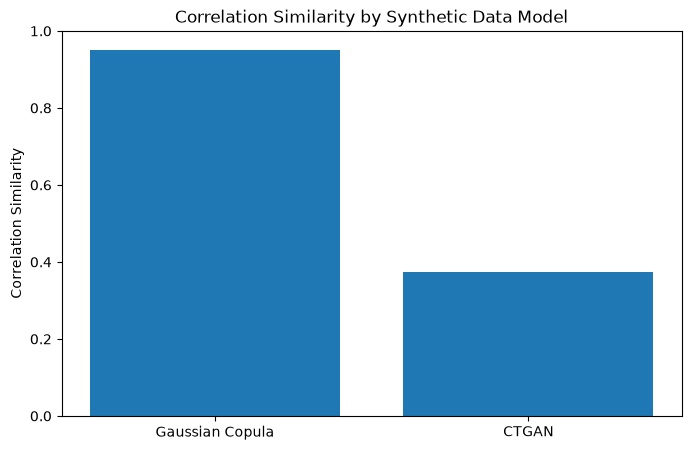

In [72]:
import matplotlib.pyplot as plt

models = comparison["model"]
correlation_scores = comparison["correlation_similarity"]

plt.figure(figsize=(8, 5))
plt.bar(models, correlation_scores)

plt.title("Correlation Similarity by Synthetic Data Model")
plt.ylabel("Correlation Similarity")
plt.ylim(0, 1)

plt.show()

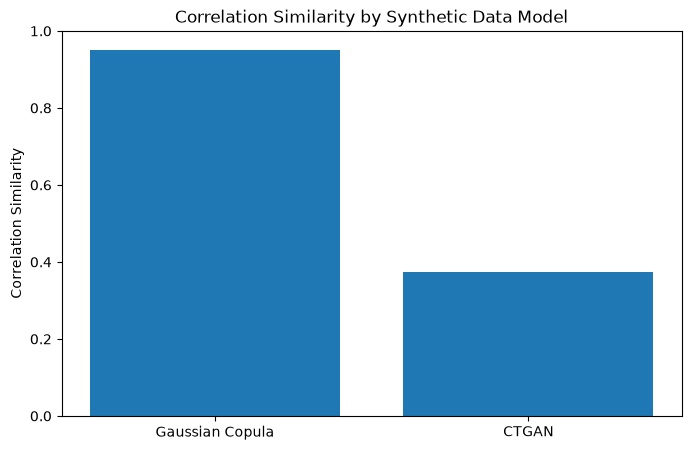

Chart saved successfully.


In [73]:
plt.figure(figsize=(8, 5))
plt.bar(models, correlation_scores)

plt.title("Correlation Similarity by Synthetic Data Model")
plt.ylabel("Correlation Similarity")
plt.ylim(0, 1)

plt.savefig(
    "../reports/figures/correlation_similarity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

In [74]:
print(ctgan_synthesizer.get_parameters())

{'enforce_min_max_values': True, 'enforce_rounding': True, 'locales': ['en_US'], 'embedding_dim': 128, 'generator_dim': (256, 256), 'discriminator_dim': (256, 256), 'generator_lr': 0.0002, 'generator_decay': 1e-06, 'discriminator_lr': 0.0002, 'discriminator_decay': 1e-06, 'batch_size': 500, 'discriminator_steps': 1, 'log_frequency': True, 'verbose': True, 'epochs': 300, 'pac': 10, 'enable_gpu': True}


In [75]:
from sdv.single_table import CTGANSynthesizer

ctgan_v2 = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=100,
    verbose=True
)

print("CTGAN v2 created successfully.")

CTGAN v2 created successfully.


In [76]:
ctgan_v2.fit(train_data)

print("CTGAN v2 training completed successfully.")

Gen. (-01.93) | Discrim. (-00.11): 100%|██████████| 300/300 [01:33<00:00,  3.20it/s]

CTGAN v2 training completed successfully.


In [77]:
ctgan_v2_synthetic_data = ctgan_v2.sample(
    num_rows=len(train_data)
)

print("CTGAN v2 synthetic data generated.")
print("Shape:", ctgan_v2_synthetic_data.shape)

ctgan_v2_synthetic_data.head()

CTGAN v2 synthetic data generated.
Shape: (800, 8)


,age,gender,income,education,city,credit_score,purchase_amount,churn
0,18,Female,43133.45,PhD,Bangalore,647,845.84,0
1,63,Male,37009.46,Master,Delhi,616,2444.74,0
2,18,Male,60109.16,Master,Delhi,585,289.04,0
3,32,Female,65668.48,PhD,Chennai,686,2371.35,0
4,57,Male,130013.84,Bachelor,Bangalore,566,1404.08,1


In [78]:
from scipy.stats import ks_2samp

for column in numeric_columns:
    statistic, p_value = ks_2samp(
        train_data[column],
        ctgan_v2_synthetic_data[column]
    )

    print(f"{column}")
    print(f"  KS statistic: {statistic:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print()

age
  KS statistic: 0.2662
  p-value: 0.0000

income
  KS statistic: 0.3625
  p-value: 0.0000

credit_score
  KS statistic: 0.2675
  p-value: 0.0000

purchase_amount
  KS statistic: 0.0650
  p-value: 0.0681



In [79]:
ctgan_v2_correlation_result = calculate_correlation_similarity(
    train_data,
    ctgan_v2_synthetic_data,
    numeric_columns
)

print(
    "Mean absolute correlation error:",
    round(
        ctgan_v2_correlation_result[
            "mean_absolute_correlation_error"
        ],
        4
    )
)

print(
    "CTGAN v2 correlation similarity:",
    round(
        ctgan_v2_correlation_result[
            "correlation_similarity"
        ],
        4
    )
)

Mean absolute correlation error: 0.4746
CTGAN v2 correlation similarity: 0.5254


In [80]:
ctgan_v2_privacy_result = calculate_exact_match_rate(
    train_data,
    ctgan_v2_synthetic_data
)

print(
    "CTGAN v2 exact matches:",
    ctgan_v2_privacy_result["exact_matches"]
)

print(
    "CTGAN v2 exact match rate:",
    f"{ctgan_v2_privacy_result['exact_match_rate']:.4f}"
)

CTGAN v2 exact matches: 0
CTGAN v2 exact match rate: 0.0000


In [81]:
ctgan_v2_nn_privacy_result = calculate_nearest_neighbor_privacy(
    train_data,
    ctgan_v2_synthetic_data,
    numeric_columns
)

print(
    "Synthetic average nearest distance:",
    round(
        ctgan_v2_nn_privacy_result[
            "synthetic_average_nearest_distance"
        ],
        4
    )
)

print(
    "Synthetic minimum nearest distance:",
    round(
        ctgan_v2_nn_privacy_result[
            "synthetic_minimum_nearest_distance"
        ],
        4
    )
)

print(
    "Training average nearest distance:",
    round(
        ctgan_v2_nn_privacy_result[
            "training_average_nearest_distance"
        ],
        4
    )
)

print(
    "Training minimum nearest distance:",
    round(
        ctgan_v2_nn_privacy_result[
            "training_minimum_nearest_distance"
        ],
        4
    )
)

print(
    "Distance ratio:",
    round(
        ctgan_v2_nn_privacy_result["distance_ratio"],
        4
    )
)

Synthetic average nearest distance: 1.0064
Synthetic minimum nearest distance: 0.082
Training average nearest distance: 0.3424
Training minimum nearest distance: 0.0738
Distance ratio: 2.9391


In [82]:
ctgan_v2_model = train_churn_model(
    ctgan_v2_synthetic_data,
    feature_columns,
    categorical_features,
    numerical_features
)

ctgan_v2_ml_result = evaluate_churn_model(
    ctgan_v2_model,
    holdout_data,
    feature_columns
)

print("CTGAN v2-trained model on real holdout:")
print(
    "Accuracy:",
    round(ctgan_v2_ml_result["accuracy"], 4)
)
print(
    "F1 score:",
    round(ctgan_v2_ml_result["f1"], 4)
)

CTGAN v2-trained model on real holdout:
Accuracy: 0.75
F1 score: 0.1379


In [83]:
ctgan_v2_f1_retention = (
    ctgan_v2_ml_result["f1"] / 0.0952
)

print(
    "CTGAN v2 F1 retention:",
    round(ctgan_v2_f1_retention, 4)
)

CTGAN v2 F1 retention: 1.4489


In [84]:
ctgan_v2_results = {
    "model": "CTGAN v2",
    "batch_size": 100,
    "ks_age": 0.2662,
    "ks_income": 0.3625,
    "ks_credit_score": 0.2675,
    "ks_purchase_amount": 0.0650,
    "correlation_similarity": 0.5254,
    "exact_match_rate": 0.0000,
    "privacy_distance_ratio": 2.9391,
    "real_accuracy": 0.7150,
    "synthetic_accuracy": 0.7500,
    "real_f1": 0.0952,
    "synthetic_f1": 0.1379,
    "f1_retention": 1.4489
}

print(ctgan_v2_results)

{'model': 'CTGAN v2', 'batch_size': 100, 'ks_age': 0.2662, 'ks_income': 0.3625, 'ks_credit_score': 0.2675, 'ks_purchase_amount': 0.065, 'correlation_similarity': 0.5254, 'exact_match_rate': 0.0, 'privacy_distance_ratio': 2.9391, 'real_accuracy': 0.715, 'synthetic_accuracy': 0.75, 'real_f1': 0.0952, 'synthetic_f1': 0.1379, 'f1_retention': 1.4489}


In [85]:
import json

with open(
    "../experiments/results/ctgan_v2_results.json",
    "w"
) as file:
    json.dump(ctgan_v2_results, file, indent=4)

print("CTGAN v2 results saved successfully.")

CTGAN v2 results saved successfully.


In [86]:
all_models_comparison = pd.DataFrame([
    baseline_results,
    ctgan_results,
    ctgan_v2_results
])

all_models_comparison[
    [
        "model",
        "ks_age",
        "ks_income",
        "ks_credit_score",
        "ks_purchase_amount",
        "correlation_similarity",
        "exact_match_rate",
        "privacy_distance_ratio",
        "synthetic_accuracy",
        "synthetic_f1",
        "f1_retention"
    ]
].round(4)

,model,ks_age,ks_income,ks_credit_score,ks_purchase_amount,correlation_similarity,exact_match_rate,privacy_distance_ratio,synthetic_accuracy,synthetic_f1,f1_retention
0,Gaussian Copula,0.0525,0.0625,0.0350,0.0413,0.9502,0.0,1.0855,0.735,0.0702,0.7368
1,CTGAN,0.0850,0.3713,0.4213,0.2188,0.3750,0.0,3.4732,0.710,0.0333,0.3501
2,CTGAN v2,0.2662,0.3625,0.2675,0.0650,0.5254,0.0,2.9391,0.750,0.1379,1.4489


In [87]:
all_models_comparison.to_csv(
    "../experiments/results/all_models_comparison.csv",
    index=False
)

print("Three-model comparison saved successfully.")

Three-model comparison saved successfully.


In [88]:
ctgan_v2_synthetic_data.to_csv(
    "../data/synthetic/ctgan_v2_data.csv",
    index=False
)

print("CTGAN v2 synthetic dataset saved successfully.")

CTGAN v2 synthetic dataset saved successfully.


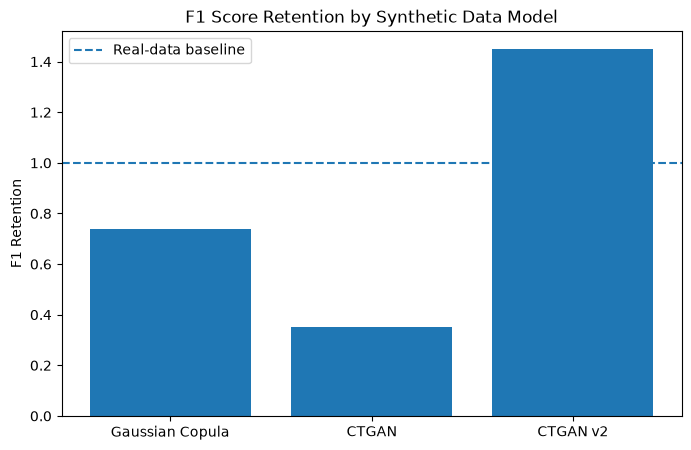

F1 retention chart saved successfully.


In [89]:
plt.figure(figsize=(8, 5))

models = all_models_comparison["model"]
f1_retention = all_models_comparison["f1_retention"]

plt.bar(models, f1_retention)

plt.title("F1 Score Retention by Synthetic Data Model")
plt.ylabel("F1 Retention")
plt.axhline(
    y=1.0,
    linestyle="--",
    label="Real-data baseline"
)

plt.legend()

plt.savefig(
    "../reports/figures/f1_retention_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("F1 retention chart saved successfully.")

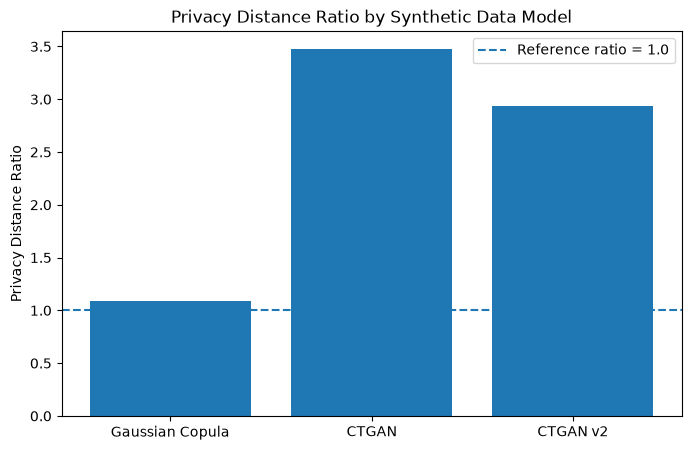

Privacy comparison chart saved successfully.


In [90]:
plt.figure(figsize=(8, 5))

models = all_models_comparison["model"]
privacy_ratios = all_models_comparison["privacy_distance_ratio"]

plt.bar(models, privacy_ratios)

plt.title("Privacy Distance Ratio by Synthetic Data Model")
plt.ylabel("Privacy Distance Ratio")

plt.axhline(
    y=1.0,
    linestyle="--",
    label="Reference ratio = 1.0"
)

plt.legend()

plt.savefig(
    "../reports/figures/privacy_distance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Privacy comparison chart saved successfully.")

In [91]:
summary_table = all_models_comparison[
    [
        "model",
        "correlation_similarity",
        "exact_match_rate",
        "privacy_distance_ratio",
        "synthetic_accuracy",
        "synthetic_f1",
        "f1_retention"
    ]
].copy()

summary_table

,model,correlation_similarity,exact_match_rate,privacy_distance_ratio,synthetic_accuracy,synthetic_f1,f1_retention
0,Gaussian Copula,0.9502,0.0,1.0855,0.735,0.0702,0.7368
1,CTGAN,0.3750,0.0,3.4732,0.710,0.0333,0.3501
2,CTGAN v2,0.5254,0.0,2.9391,0.750,0.1379,1.4489


In [92]:
summary_table.to_csv(
    "../experiments/results/model_summary.csv",
    index=False
)

print("Model summary saved successfully.")

Model summary saved successfully.


In [93]:
import os

result_files = [
    "../experiments/results/gaussian_copula_results.json",
    "../experiments/results/ctgan_results.json",
    "../experiments/results/ctgan_v2_results.json",
    "../experiments/results/all_models_comparison.csv",
    "../experiments/results/model_summary.csv",
    "../reports/figures/correlation_similarity_comparison.png",
    "../reports/figures/f1_retention_comparison.png",
    "../reports/figures/privacy_distance_comparison.png",
]

for file_path in result_files:
    print(
        "✓" if os.path.exists(file_path) else "✗",
        file_path
    )

✓ ../experiments/results/gaussian_copula_results.json
✓ ../experiments/results/ctgan_results.json
✓ ../experiments/results/ctgan_v2_results.json
✓ ../experiments/results/all_models_comparison.csv
✓ ../experiments/results/model_summary.csv
✓ ../reports/figures/correlation_similarity_comparison.png
✓ ../reports/figures/f1_retention_comparison.png
✓ ../reports/figures/privacy_distance_comparison.png


In [95]:
from src.evaluation.evaluation_pipeline import evaluate_synthetic_data

gaussian_synthetic_data = pd.read_csv(
    "../data/synthetic/gaussian_copula_data.csv"
)

test_results = evaluate_synthetic_data(
    train_data=train_data,
    synthetic_data=gaussian_synthetic_data,
    numerical_columns=numerical_columns
)

print(test_results)

{'ks_metrics': {'age': {'ks_statistic': 0.0525, 'p_value': 0.2202893027767536}, 'income': {'ks_statistic': 0.0625, 'p_value': 0.08785943060284065}, 'credit_score': {'ks_statistic': 0.035, 'p_value': 0.7115715557110696}, 'purchase_amount': {'ks_statistic': 0.04125, 'p_value': 0.5043163045518106}}, 'correlation': {'mean_absolute_correlation_error': 0.049765149713620636, 'correlation_similarity': 0.9502348502863793}, 'exact_match': {'exact_matches': 0, 'exact_match_rate': 0.0}, 'privacy_distance': {'synthetic_average_nearest_distance': 0.3716934567912702, 'synthetic_minimum_nearest_distance': 0.0694297327361282, 'training_average_nearest_distance': 0.342415257698215, 'training_minimum_nearest_distance': 0.07383775913496782, 'distance_ratio': 1.0855049488444797}}


In [96]:
ctgan_v2_synthetic_data = pd.read_csv(
    "../data/synthetic/ctgan_v2_data.csv"
)

ctgan_v2_test_results = evaluate_synthetic_data(
    train_data=train_data,
    synthetic_data=ctgan_v2_synthetic_data,
    numerical_columns=numerical_columns
)

print(ctgan_v2_test_results)


{'ks_metrics': {'age': {'ks_statistic': 0.26625, 'p_value': 2.443626976431166e-25}, 'income': {'ks_statistic': 0.3625, 'p_value': 4.1678739829141644e-47}, 'credit_score': {'ks_statistic': 0.2675, 'p_value': 1.4146045711687321e-25}, 'purchase_amount': {'ks_statistic': 0.065, 'p_value': 0.06807405222411245}}, 'correlation': {'mean_absolute_correlation_error': 0.4745581633005076, 'correlation_similarity': 0.5254418366994924}, 'exact_match': {'exact_matches': 0, 'exact_match_rate': 0.0}, 'privacy_distance': {'synthetic_average_nearest_distance': 1.0064046830275593, 'synthetic_minimum_nearest_distance': 0.08203733721130592, 'training_average_nearest_distance': 0.342415257698215, 'training_minimum_nearest_distance': 0.07383775913496782, 'distance_ratio': 2.9391350426170146}}


In [97]:
exact_match_rate = ctgan_v2_test_results["exact_match"]["exact_match_rate"]

if exact_match_rate == 0:
    print("Privacy check passed: no exact training-record matches found.")
else:
    print(
        f"Warning: exact training-record match rate = "
        f"{exact_match_rate:.4f}"
    )

Privacy check passed: no exact training-record matches found.


In [98]:
from src.evaluation.privacy_metrics import check_exact_match_privacy

privacy_check = check_exact_match_privacy(
    train_data,
    ctgan_v2_synthetic_data
)

print(privacy_check)

ImportError: cannot import name 'check_exact_match_privacy' from 'src.evaluation.privacy_metrics' (c:\Users\NISHCHAL\Desktop\synthetic-data-generator\src\evaluation\privacy_metrics.py)

In [99]:
import importlib
import src.evaluation.privacy_metrics as privacy_metrics

importlib.reload(privacy_metrics)

print("Privacy metrics module reloaded successfully.")

Privacy metrics module reloaded successfully.


In [100]:
privacy_check = privacy_metrics.check_exact_match_privacy(
    train_data,
    ctgan_v2_synthetic_data
)

print(privacy_check)

{'exact_matches': 0, 'exact_match_rate': 0.0, 'status': 'No exact training-record matches found.'}


In [101]:
{'exact_matches': 0, 'exact_match_rate': 0.0, 'status': 'No exact training-record matches found.'}

{'exact_matches': 0,
 'exact_match_rate': 0.0,
 'status': 'No exact training-record matches found.'}

In [102]:
import importlib
import src.evaluation.evaluation_pipeline as evaluation_pipeline

importlib.reload(evaluation_pipeline)

print("Evaluation pipeline reloaded successfully.")

Evaluation pipeline reloaded successfully.


In [103]:
test_results = evaluation_pipeline.evaluate_synthetic_data(
    train_data=train_data,
    synthetic_data=ctgan_v2_synthetic_data,
    numerical_columns=numerical_columns
)

print(test_results)

{'ks_metrics': {'age': {'ks_statistic': 0.26625, 'p_value': 2.443626976431166e-25}, 'income': {'ks_statistic': 0.3625, 'p_value': 4.1678739829141644e-47}, 'credit_score': {'ks_statistic': 0.2675, 'p_value': 1.4146045711687321e-25}, 'purchase_amount': {'ks_statistic': 0.065, 'p_value': 0.06807405222411245}}, 'correlation': {'mean_absolute_correlation_error': 0.4745581633005076, 'correlation_similarity': 0.5254418366994924}, 'exact_match': {'exact_matches': 0, 'exact_match_rate': 0.0, 'status': 'No exact training-record matches found.'}, 'privacy_distance': {'synthetic_average_nearest_distance': 1.0064046830275593, 'synthetic_minimum_nearest_distance': 0.08203733721130592, 'training_average_nearest_distance': 0.342415257698215, 'training_minimum_nearest_distance': 0.07383775913496782, 'distance_ratio': 2.9391350426170146}}


In [104]:
from src.evaluation.summary import create_evaluation_summary

ctgan_v2_summary = create_evaluation_summary(
    model_name="CTGAN v2",
    evaluation_results=test_results
)

print(ctgan_v2_summary)

{'model': 'CTGAN v2', 'correlation_similarity': 0.5254, 'exact_match_rate': 0.0, 'privacy_distance_ratio': 2.9391}


In [105]:
import json

with open(
    "../experiments/results/ctgan_v2_summary.json",
    "w"
) as file:
    json.dump(
        ctgan_v2_summary,
        file,
        indent=4
    )

print("CTGAN v2 summary saved successfully.")

CTGAN v2 summary saved successfully.


In [106]:
import os

summary_path = "../experiments/results/ctgan_v2_summary.json"

if os.path.exists(summary_path):
    print("✓ CTGAN v2 summary file exists.")
else:
    print("✗ Summary file was not found.")

✓ CTGAN v2 summary file exists.


In [107]:
final_results = pd.DataFrame([
    create_evaluation_summary(
        "Gaussian Copula",
        evaluate_synthetic_data(
            train_data,
            pd.read_csv("../data/synthetic/gaussian_copula_data.csv"),
            numerical_columns
        )
    ),
    create_evaluation_summary(
        "CTGAN",
        evaluate_synthetic_data(
            train_data,
            pd.read_csv("../data/synthetic/ctgan_data.csv"),
            numerical_columns
        )
    ),
    create_evaluation_summary(
        "CTGAN v2",
        evaluate_synthetic_data(
            train_data,
            pd.read_csv("../data/synthetic/ctgan_v2_data.csv"),
            numerical_columns
        )
    )
])

final_results

,model,correlation_similarity,exact_match_rate,privacy_distance_ratio
0,Gaussian Copula,0.9502,0.0,1.0855
1,CTGAN,0.3750,0.0,3.4732
2,CTGAN v2,0.5254,0.0,2.9391


In [108]:
final_results.to_csv(
    "../experiments/results/final_evaluation_summary.csv",
    index=False
)

print("Final evaluation summary saved successfully.")


Final evaluation summary saved successfully.


In [109]:
import os

final_results_path = "../experiments/results/final_evaluation_summary.csv"

if os.path.exists(final_results_path):
    print("✓ Final evaluation summary exists.")
else:
    print("✗ Final evaluation summary was not found.")

✓ Final evaluation summary exists.


In [110]:
from src.evaluation.summary import load_final_results

loaded_results = load_final_results(
    "../experiments/results/final_evaluation_summary.csv"
)

loaded_results

ImportError: cannot import name 'load_final_results' from 'src.evaluation.summary' (c:\Users\NISHCHAL\Desktop\synthetic-data-generator\src\evaluation\summary.py)

In [111]:
import importlib
import src.evaluation.summary as summary

importlib.reload(summary)

print("Summary module reloaded successfully.")

Summary module reloaded successfully.


In [112]:
loaded_results = summary.load_final_results(
    "../experiments/results/final_evaluation_summary.csv"
)

loaded_results

,model,correlation_similarity,exact_match_rate,privacy_distance_ratio
0,Gaussian Copula,0.9502,0.0,1.0855
1,CTGAN,0.3750,0.0,3.4732
2,CTGAN v2,0.5254,0.0,2.9391
